# Phase 3A-1: progression and reset diagnostics

**DIAGNOSTIC / NOT A METHOD LOCK.** Phase 2C remains LOCKED / COMPLETE — RESTRICTED SEMANTIC SCOPE.

## 1. Purpose and population
Describe observable action displacement, retreat, runs, interruption and recovery before human episode-boundary review. No episode/reset labels, sequence thresholds, outcomes or tactical findings are created. Run `.venv/Scripts/python.exe scripts/progression_diagnostics.py` first; this notebook reads derived evidence offline.

Only Leverkusen Pass/Carry events with explicit valid endpoints **and validated Phase 2C frames** supply action vectors. This conservative diagnostic subset is narrower than all recorded Pass/Carry events. Unsupported, unlinked and opponent events remain full context. Validated opponent and Pressure anchors are retained separately, not treated as Leverkusen ball actions.


In [1]:
from pathlib import Path
import html
import pandas as pd
from IPython.display import display, HTML, Image

root=Path.cwd()
if not (root/'config/project.yaml').exists():
    root=root.parent
revision='533862946a73608c134d18b78226b6371ce7173c'
def read(name):
    t=pd.read_csv(root/'outputs/diagnostics'/f'phase3a1_{name}.csv')
    assert t.statsbomb_revision.eq(revision).all(), 'Wrong source revision'
    return t.drop(columns='statsbomb_revision')

def figure(name):
    display(Image(filename=str(root/'outputs/figures'/f'phase3a1_{name}.png')))

run=read('run_summary')
p=read('possession_progression_summary')
assert len(p)==2888
assert p.total_event_count.sum()==86025
assert p.validated_spatial_anchor_count.sum()==46143
assert p.unsupported_360_frame_count.sum()==28504
assert run.anchor_gap_intervals.iloc[0]==43431
assert not p[['match_id','period','possession_id','possession_team_id']].duplicated().any()
display(run.T)
display(read('data_quality_summary').T)
display(read('action_scope_inventory'))


,0
generated_at_utc,2026-09-10T19:15:47.198082+00:00
phase3a1_status,DIAGNOSTIC / NOT A METHOD LOCK
phase2c_status,LOCKED / COMPLETE — RESTRICTED SEMANTIC SCOPE
matches,34
possession_groups,2888
retained_events,86025
validated_anchors,46143
anchor_gap_intervals,43431
safe_action_vectors,37984
raw_persisted,False


,0
full_events_retained,86025
safe_actions,37984
possessions_without_safe_actions,226
explicit_own_vectors_excluded_by_scope,5713
validated_own_vectors_missing_endpoint,0
safe_actions_with_oob_coordinates,0
opponent_validated_anchors,6846
zero_backward_denominators,418
zero_action_time_gaps,0
anchor_gap_intervals,43431


,event_type,action_status,explicit_vector_available,event_count,match_count
0,Carry,safe_validated_frame_vector,True,17892,34
1,Carry,unsupported_or_unlinked_frame,True,2249,34
2,Pass,safe_validated_frame_vector,True,20092,34
3,Pass,unsupported_or_unlinked_frame,True,3464,34


## 2. Action displacement
Delta-x/y and Euclidean displacement use explicit start/end coordinates in the validated Leverkusen attacking reference. Presentation bins are dx < -20, [-20,-10), [-10,0), [0,10), [10,20), dx >=20 native units. Exact zero is separately counted in the numeric summary. These are neither progressive-pass definitions nor reset thresholds.


,event_type,count,mean,median,p05,p10,p25,p75,p90,p95,p99,minimum,maximum,pct_positive,pct_zero,pct_negative
0,Pass,20092,2.988319,2.3,-15.0,-11.6,-5.7,9.8,16.9,23.3,47.809,-56.9,91.6,57.759307,1.065101,41.175592
1,Carry,17892,2.113246,0.2,-4.7,-2.4,-0.3,3.0,8.7,14.2,28.518,-29.7,77.8,52.168567,18.974961,28.856472
2,Pass + Carry,37984,2.576124,0.6,-12.2,-8.1,-1.7,6.8,14.1,20.2,40.200,-56.9,91.6,55.125842,9.501369,35.372789


,event_type,displacement_bin,count,percentage
0,Carry,dx < -20,12,0.067069
1,Carry,"[-20,-10)",141,0.788062
2,Carry,"[-10,0)",5010,28.001341
3,Carry,"[0,10)",11203,62.614576
4,Carry,"[10,20)",1057,5.907668
5,Carry,dx >= 20,469,2.621283
6,Pass,dx < -20,419,2.085407
7,Pass,"[-20,-10)",2158,10.740593
8,Pass,"[-10,0)",5696,28.349592
9,Pass,"[0,10)",6861,34.147920


,starting_x_band,count,mean,median,p05,p10,p25,p75,p90,p95,p99,minimum,maximum,pct_backward,backward_at_least_5,backward_at_least_15,backward_at_least_30
0,below 0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
1,"[0,30)",3940,7.411168,3.2,-9.8,-5.30,0.00,12.0,24.41,40.905,61.261,-27.1,91.6,24.746193,405,87,0
2,"[30,60)",11947,3.106370,1.2,-12.0,-7.60,-1.20,7.7,14.50,20.600,42.200,-45.7,78.1,33.054323,1757,362,70
3,"[60,80)",11514,1.996795,0.3,-12.2,-8.50,-1.90,6.4,13.60,18.800,33.774,-56.9,56.9,36.512072,2067,308,37
4,"[80,100)",7873,1.577162,0.2,-12.4,-8.50,-2.30,5.8,12.90,17.100,26.228,-50.9,37.2,37.419027,1410,200,7
5,"[100,120)",2539,-1.074242,0.0,-13.6,-10.12,-3.75,2.1,6.40,9.200,13.824,-32.9,19.2,46.987003,542,97,2
6,120 or above,171,-6.671930,-5.8,-14.6,-11.10,-8.00,-4.1,-3.30,-2.000,-0.070,-29.2,0.0,98.830409,103,7,0


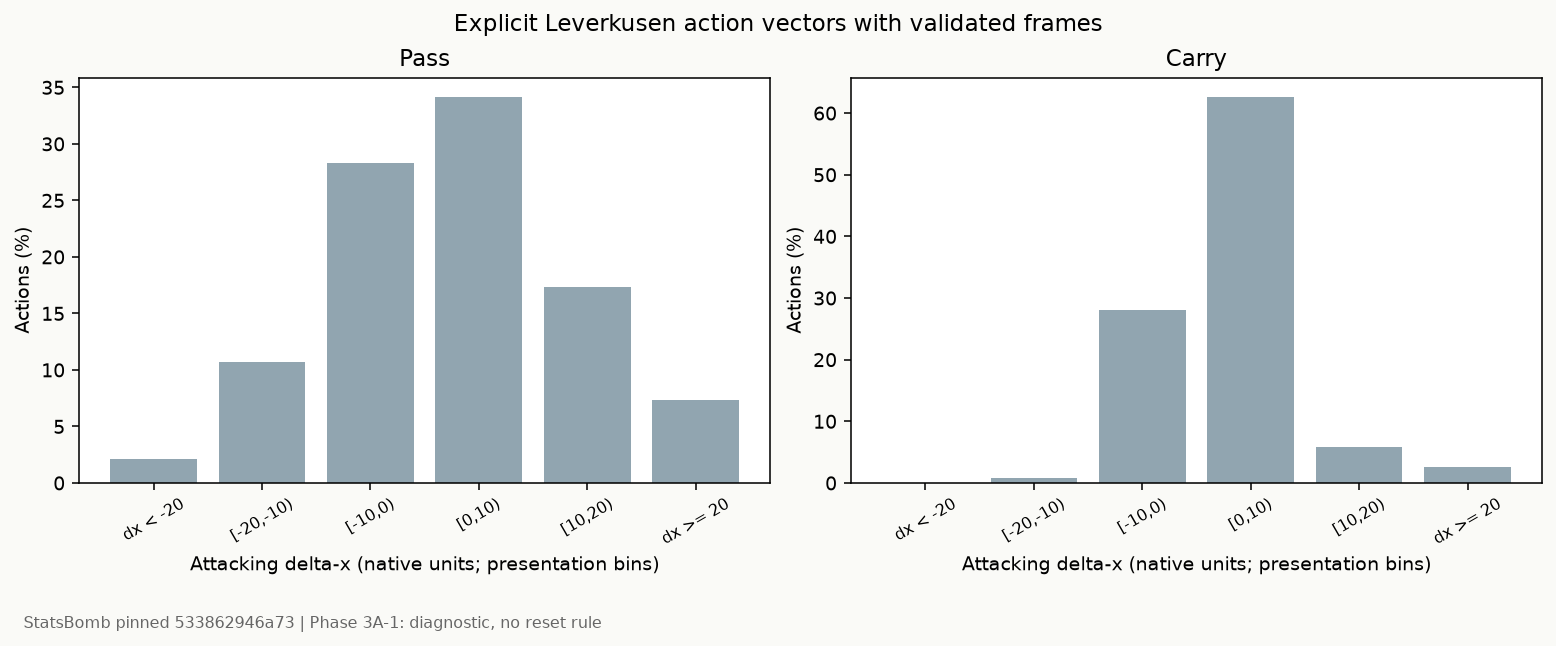

In [2]:
display(read('action_displacement_summary'))
display(read('action_displacement_bins'))
display(read('field_position_summary'))
figure('action_displacement')


## 3. Possession progression paths
Each safe action contributes its recorded start then end, in action order. Net progression is final end-x minus first start-x. Positive and negative components sum **within explicit vectors only**. The difference between those sums and net progression is the sum of inter-action coordinate jumps; no movement is inferred across missing actions. Empty safe paths retain missing measurements. A zero backward denominator gives a missing ratio plus an explicit flag.


In [3]:
display(read('possession_distributions'))
display(p.head(8))


,measure,count,mean,median,p05,p10,p25,p75,p90,p95,p99,minimum,maximum,missing_possessions
0,net_x_progression,2662,32.214613,31.00000,-16.790000,-7.390000,6.700000,56.975000,78.1000,89.195000,102.93900,-101.2,117.100,226
1,cumulative_forward_x,2662,67.589369,57.75000,1.000000,7.220000,26.200000,94.000000,140.1900,176.175000,250.10700,0.0,382.100,226
2,cumulative_backward_x,2662,30.830729,18.10000,0.000000,0.000000,3.125000,44.600000,79.1900,108.890000,176.25100,-0.0,307.100,226
3,forward_to_backward_ratio,2244,7.826294,2.12221,0.020718,0.625002,1.271583,4.270447,11.2250,24.692636,111.38000,0.0,759.000,644
4,maximum_retreat_from_peak,2662,22.457062,16.80000,0.000000,0.000000,4.425000,33.900000,53.2000,68.100000,94.66800,0.0,113.000,226
5,maximum_single_backward_action,2662,10.907250,9.90000,0.000000,0.000000,2.700000,15.800000,23.2000,28.900000,40.10000,0.0,56.900,226
6,inter_action_x_jump_sum,2662,-4.544027,0.00000,-48.995000,-30.260000,-6.775000,0.600000,15.1000,25.695000,45.81700,-174.9,98.600,226
7,possession_duration_seconds,2888,27.891793,17.88200,0.940400,2.387000,7.002500,39.651750,66.5823,87.955100,135.02731,0.0,181.388,0
8,total_event_count,2888,29.787050,20.00000,3.000000,5.000000,9.000000,40.000000,68.0000,91.000000,134.13000,1.0,233.000,0
9,validated_spatial_anchor_count,2888,15.977493,10.00000,0.000000,1.000000,4.000000,22.000000,38.3000,52.000000,75.13000,0.0,120.000,0


,match_id,period,possession_id,possession_team_id,first_event_index,last_event_index,first_timestamp,last_timestamp,possession_duration_seconds,total_event_count,...,maximum_single_backward_action,positive_action_count,negative_action_count,zero_action_count,inter_action_x_jump_sum,maximum_positive_run_actions,maximum_negative_run_actions,maximum_nonpositive_run_actions,retreat_excursion_count,observed_recovery_count
0,3895052,1,1,904,1,4,00:00:00.000,00:00:00.000,0.000,4,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
1,3895052,1,6,904,96,111,00:01:52.588,00:01:59.403,6.815,16,...,0.6,3.0,3.0,0.0,-5.3,3,3,3,1,0
2,3895052,1,9,904,118,130,00:02:17.739,00:02:26.455,8.716,13,...,0.0,4.0,0.0,1.0,-21.5,3,0,0,1,0
3,3895052,1,12,904,162,219,00:03:08.800,00:04:08.334,59.534,58,...,37.4,12.0,12.0,0.0,-1.5,3,7,7,3,3
4,3895052,1,15,904,256,264,00:04:58.409,00:05:04.498,6.089,9,...,6.6,4.0,1.0,0.0,0.4,3,1,1,1,1
5,3895052,1,17,904,300,385,00:05:39.491,00:06:50.291,70.800,86,...,17.3,22.0,16.0,1.0,9.0,4,4,4,4,4
6,3895052,1,19,904,407,441,00:07:24.168,00:07:51.754,27.586,35,...,7.0,10.0,1.0,1.0,-11.3,7,1,1,1,1
7,3895052,1,22,904,478,478,00:09:23.561,00:09:23.561,0.000,1,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0


## 4. Retreat from running peak
Peak and retreat use action-ordered start/end vertices. An endpoint is not a second independently observed 360 state, and repeated vertices remain in the distribution. The 5/10/15/20/25/30/40-unit sweep inventories possessions without choosing a reset value. Field-depth bands are presentation choices, not tactical zones.


,population,count,mean,median,p05,p10,p25,p75,p90,p95,p99,minimum,maximum
0,all_action_vertices,75968,14.218766,8.5,0.0,0.0,0.000,21.8,37.8,49.2,73.033,0.0,113.0
1,possession_maximum,2662,22.457062,16.8,0.0,0.0,4.425,33.9,53.2,68.1,94.668,0.0,113.0


,retreat_at_least,possessions,pct_all_possessions,pct_measurable_possessions
0,5,1965,68.040166,73.816679
1,10,1687,58.414127,63.373403
2,15,1429,49.480609,53.681443
3,20,1195,41.378116,44.891059
4,25,972,33.656510,36.513899
5,30,791,27.389197,29.714500
6,40,510,17.659280,19.158527


,first_reached_x_at_least,count,mean,median,p05,p10,p25,p75,p90,p95,p99,minimum,maximum
0,30,2591,22.597916,17.20,0.0,0.0,3.7,34.300,53.70,68.350,95.430,0.0,113.0
1,60,2273,21.865200,15.00,0.0,0.0,0.6,34.300,56.70,69.740,96.284,0.0,113.0
2,80,1872,20.309402,10.35,0.0,0.0,0.0,32.725,56.88,72.545,98.658,0.0,113.0
3,100,1344,18.327976,5.75,0.0,0.0,0.0,28.925,55.17,71.870,100.228,0.0,113.0


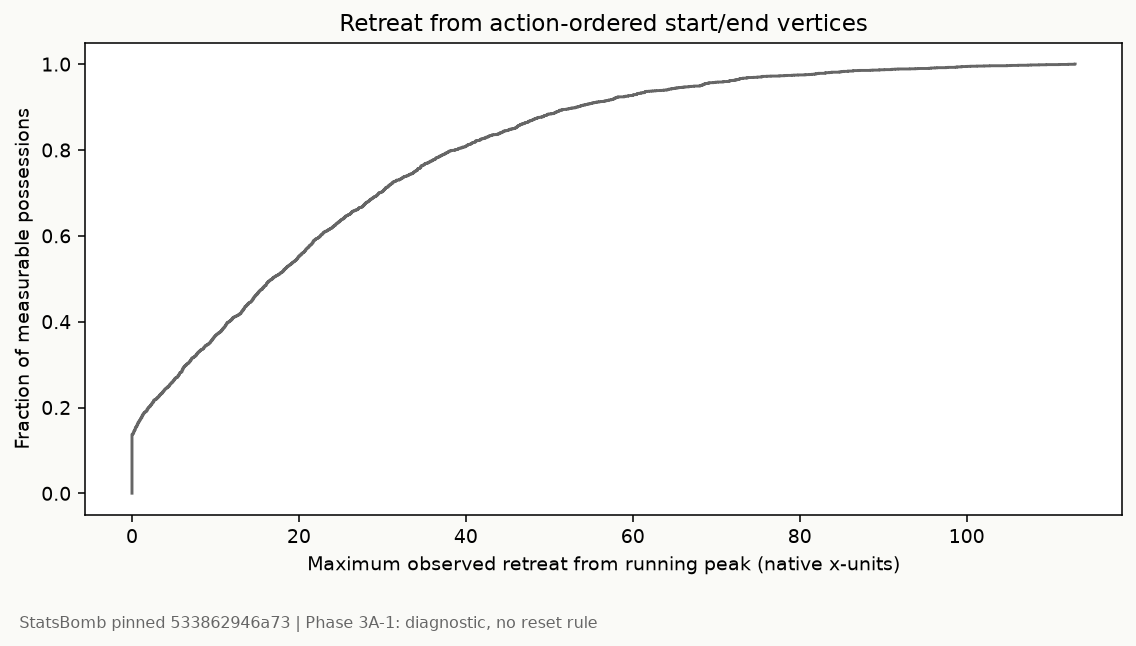

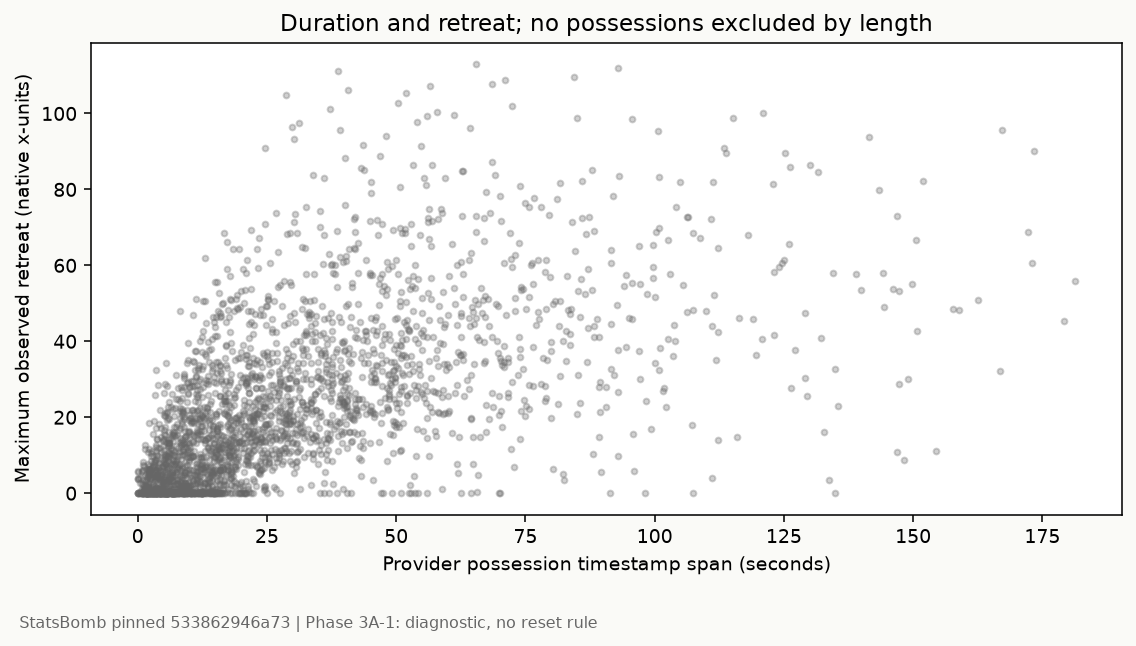

In [4]:
display(read('retreat_distributions'))
display(read('retreat_threshold_inventory'))
display(read('retreat_after_depth_inventory'))
figure('maximum_retreat_ecdf')
figure('duration_retreat')


## 5. Forward/backward runs
Strict runs are maximal consecutive positive or negative delta-x values in the **usable action subsequence**. Contextual events can intervene; their counts are retained. Zero ends strict runs. A separately labeled non-positive alternative allows exact zero while requiring at least one negative action; no near-zero tolerance is selected. Runs are descriptive, not attacking episodes or uninterrupted ball-control intervals.


In [5]:
display(read('run_statistics'))


,run_kind,measure,count,mean,median,p05,p10,p25,p75,p90,p95,p99,minimum,maximum
0,negative,action_count,8319,1.615098,1.0000,1.0,1.0,1.000,2.00000,3.0000,4.00000,5.00000,1.0,9.000
1,negative,cumulative_x_component,8319,9.865537,7.5000,0.5,0.9,3.050,13.40000,21.5000,28.91000,46.20000,0.1,78.800
2,negative,timestamp_span_seconds,8319,0.967247,0.0000,0.0,0.0,0.000,1.22550,3.1216,4.66510,8.84310,0.0,32.608
3,negative,maximum_single_component,8319,7.994470,6.8000,0.5,0.9,2.800,11.30000,15.9000,20.20000,33.60000,0.1,56.900
4,negative,start_x,8319,70.867941,70.9000,28.2,38.1,54.200,88.20000,104.5000,112.30000,120.00000,3.3,120.000
5,negative,end_x,8319,60.815326,62.2000,13.2,24.6,43.450,78.85000,94.8000,104.80000,115.08200,0.7,119.900
6,negative,intervening_context_events,8319,0.559803,0.0000,0.0,0.0,0.000,1.00000,2.0000,3.00000,6.82000,0.0,24.000
7,nonpositive,action_count,7804,2.060097,2.0000,1.0,1.0,1.000,3.00000,4.0000,5.00000,7.00000,1.0,12.000
8,nonpositive,cumulative_x_component,7804,10.516581,7.9000,0.5,0.9,3.300,14.40000,22.9000,30.50000,46.89700,0.1,78.800
9,nonpositive,timestamp_span_seconds,7804,1.494456,0.6085,0.0,0.0,0.000,2.03900,4.2874,6.28445,10.91325,0.0,32.608


## 6. Timing and recycling
Three separate layers use source event timestamps: complete event context, safe Leverkusen vectors and all validated spatial anchors. No gap crosses match, period or provider possession boundaries. Endpoint arrival times are not available: action-path and recovery durations are differences between their source **action-start timestamps**, not physical travel/recycling times. Runs report first-to-last action-start span. Long gaps are retained.


In [6]:
timing=read('temporal_gap_summary')
a=timing.set_index('layer').loc['validated_anchors']
assert a['count']==43431
assert abs(a['median']-1.103)<1e-9
assert abs(a['p90']-3.214)<1e-9
display(timing)
display(read('spatial_anchor_displacement_summary').head(20))


,layer,count,mean,median,p05,p10,p25,p75,p90,p95,p99,minimum,maximum,pct_above_3_seconds,pct_above_5_seconds,pct_above_10_seconds,pct_above_15_seconds
0,full_events,83137,0.968901,0.632,0.000,0.000,0.000,1.309,2.173,3.0632,5.64364,0.000,145.042,5.240747,1.419344,0.309128,0.203279
1,safe_actions,35322,1.795142,1.228,0.196,0.534,0.837,1.985,3.762,5.3860,9.36369,0.002,34.145,14.248910,5.911330,0.801200,0.167035
2,validated_anchors,43431,1.525092,1.103,0.098,0.249,0.665,1.765,3.214,4.5825,7.87040,0.000,31.708,11.231609,4.033985,0.423661,0.099008


,previous_anchor_type,next_anchor_type,previous_event_team_id,next_event_team_id,count,mean,median,p05,p10,p25,p75,p90,p95,p99,minimum,maximum
0,Carry,Carry,169,169,1,-19.300000,-19.30,-19.300,-19.30,-19.300,-19.300,-19.30,-19.300,-19.300,-19.3,-19.3
1,Carry,Carry,169,904,3,-32.766667,-46.70,-47.060,-47.02,-46.900,-25.600,-12.94,-8.720,-5.344,-47.1,-4.5
2,Carry,Carry,172,172,1,-3.300000,-3.30,-3.300,-3.30,-3.300,-3.300,-3.30,-3.300,-3.300,-3.3,-3.3
3,Carry,Carry,172,904,2,-21.850000,-21.85,-42.865,-40.53,-33.525,-10.175,-3.17,-0.835,1.033,-45.2,1.5
4,Carry,Carry,174,904,2,3.550000,3.55,1.525,1.75,2.425,4.675,5.35,5.575,5.755,1.3,5.8
5,Carry,Carry,175,904,5,-7.820000,-1.10,-20.540,-19.88,-17.900,0.100,0.64,0.820,0.964,-21.2,1.0
6,Carry,Carry,177,177,1,-9.000000,-9.00,-9.000,-9.00,-9.000,-9.000,-9.00,-9.000,-9.000,-9.0,-9.0
7,Carry,Carry,177,904,2,-20.000000,-20.00,-33.230,-31.76,-27.350,-12.650,-8.24,-6.770,-5.594,-34.7,-5.3
8,Carry,Carry,179,904,3,-18.133333,-9.90,-39.960,-36.62,-26.600,-5.550,-2.94,-2.070,-1.374,-43.3,-1.2
9,Carry,Carry,180,180,1,-11.700000,-11.70,-11.700,-11.70,-11.700,-11.700,-11.70,-11.700,-11.700,-11.7,-11.7


## 7. Recovery after retreat
An exploratory drawdown excursion starts at the first observed vertex below the running peak, and ends at the first subsequent vertex at or above that prior level. Equal-peak observations update its time to the most recent observation. Unrecovered excursions are censored at the last safe observation: no observed return does not establish failure to recover in the full football sequence. Recovery times are conditional on observation and are not outcome success labels.


In [7]:
display(read('recovery_summary'))
display(read('recovery_inventory').head(10))


,recovered_previous_peak,excursion_count,new_peak_count,measure,count,mean,median,p05,p10,p25,p75,p90,p95,p99,minimum,maximum
0,False,1262,0,retreat_size,1262,25.223693,17.1000,0.700,1.4000,5.125,39.50000,61.4900,75.37500,100.15600,0.100,113.000
1,False,1262,0,time_to_recover_previous_peak,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,False,1262,0,events_to_recover_previous_peak,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,False,1262,0,observed_followup_seconds,1262,12.497602,4.6745,0.000,0.0000,0.000,16.46175,36.5699,49.10705,84.55516,0.000,172.465
4,False,1262,0,time_peak_to_trough,1262,7.319269,3.0045,0.000,0.0000,0.000,9.92325,20.9783,28.82460,55.24575,0.000,81.491
5,False,1262,0,time_trough_to_recovery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,True,3519,3497,retreat_size,3519,14.803893,10.6000,0.600,1.2000,4.400,20.50000,34.3000,44.64000,67.31000,0.100,108.700
7,True,3519,3497,time_to_recover_previous_peak,3519,9.040517,5.0080,0.728,0.9938,1.972,11.23350,22.1512,31.87540,58.56976,0.013,132.191
8,True,3519,3497,events_to_recover_previous_peak,3519,10.497300,6.0000,1.000,2.0000,3.000,13.00000,24.2000,36.00000,63.00000,1.000,163.000
9,True,3519,3497,observed_followup_seconds,3519,9.040517,5.0080,0.728,0.9938,1.972,11.23350,22.1512,31.87540,58.56976,0.013,132.191


,match_id,period,possession_id,possession_team_id,peak_event_index,onset_event_index,trough_event_index,last_observed_event_index,previous_peak_x,trough_x,retreat_size,recovered_previous_peak,new_peak_reached,time_to_recover_previous_peak,events_to_recover_previous_peak,observed_followup_seconds,time_peak_to_trough,time_trough_to_recovery,censored_at_last_safe_observation
0,3895052,1,6,904,101,101,110,110,100.0,92.2,7.8,False,False,NaN,NaN,2.970,2.970,NaN,True
1,3895052,1,9,904,124,127,127,127,114.9,93.2,21.7,False,False,NaN,NaN,4.058,4.058,NaN,True
2,3895052,1,12,904,164,164,164,166,83.7,81.7,2.0,True,True,0.445,2.0,0.445,0.000,0.445,False
3,3895052,1,12,904,166,168,168,171,88.0,66.7,21.3,True,True,5.437,5.0,5.437,0.705,4.732,False
4,3895052,1,12,904,171,176,192,217,97.2,14.2,83.0,True,True,49.153,46.0,49.153,26.113,23.040,False
5,3895052,1,15,904,261,261,261,263,69.5,62.9,6.6,True,True,0.453,2.0,0.453,0.000,0.453,False
6,3895052,1,17,904,308,308,309,319,44.9,28.5,16.4,True,True,6.800,11.0,6.800,0.080,6.720,False
7,3895052,1,17,904,323,325,328,330,52.6,38.6,14.0,True,True,4.009,7.0,4.009,2.534,1.475,False
8,3895052,1,17,904,341,341,341,344,85.4,83.7,1.7,True,True,0.977,3.0,0.977,0.000,0.977,False
9,3895052,1,17,904,344,353,357,384,89.6,56.4,33.2,True,True,27.600,40.0,27.600,8.234,19.366,False


## 8. Long possessions and deterministic review cases
The extreme manifest unions the top 20 by duration, event count, anchor count and maximum retreat, retaining ranking reasons. A separate bounded manifest selects up to 26 cases across descriptive strata and extreme leaders. Selection can use Shot only as context, never goal, xG or future effectiveness. Expand complete event-context tables below; unsupported rows have missing action coordinates and peaks, never forward-filled values.


,duration_above_seconds,possessions,percentage
0,30,965,33.414127
1,60,354,12.257618
2,90,134,4.639889
3,120,53,1.835180


,match_id,period,possession_id,possession_duration_seconds,total_event_count,validated_spatial_anchor_count,maximum_retreat_from_peak,retreat_excursion_count,ranking_reasons
0,3895060,1,23,56.045,50,22,99.4,2,maximum_retreat_from_peak:rank_17
1,3895060,1,68,111.054,145,85,44.0,5,validated_spatial_anchor_count:rank_19
2,3895060,2,151,124.101,159,94,59.5,6,total_event_count:rank_17;validated_spatial_an...
3,3895067,1,3,166.807,105,61,32.3,9,possession_duration_seconds:rank_7
4,3895067,1,25,72.490,52,26,102.1,2,maximum_retreat_from_peak:rank_12
5,3895067,2,102,179.146,59,36,45.4,2,possession_duration_seconds:rank_2
6,3895067,2,133,154.401,56,30,11.1,5,possession_duration_seconds:rank_11
7,3895074,2,150,147.323,118,63,28.8,6,possession_duration_seconds:rank_18
8,3895086,1,23,181.388,197,98,55.9,4,possession_duration_seconds:rank_1;total_event...
9,3895107,1,64,84.974,93,49,98.9,3,maximum_retreat_from_peak:rank_18


,match_id,period,possession_id,selection_reasons
0,3895052,1,1,sparse_anchors
1,3895052,1,6,multiple_backward_actions;shot_context
2,3895052,1,9,nonnegative_action_vectors
3,3895052,1,12,large_single_backward_action;multiple_backward...
4,3895052,1,15,retreat_then_observed_recovery
5,3895052,1,19,shot_context
6,3895052,1,22,sparse_anchors
7,3895052,1,46,nonnegative_action_vectors
8,3895052,2,92,short_high_net_rate
9,3895052,2,120,multiple_peak_excursions;many_anchors


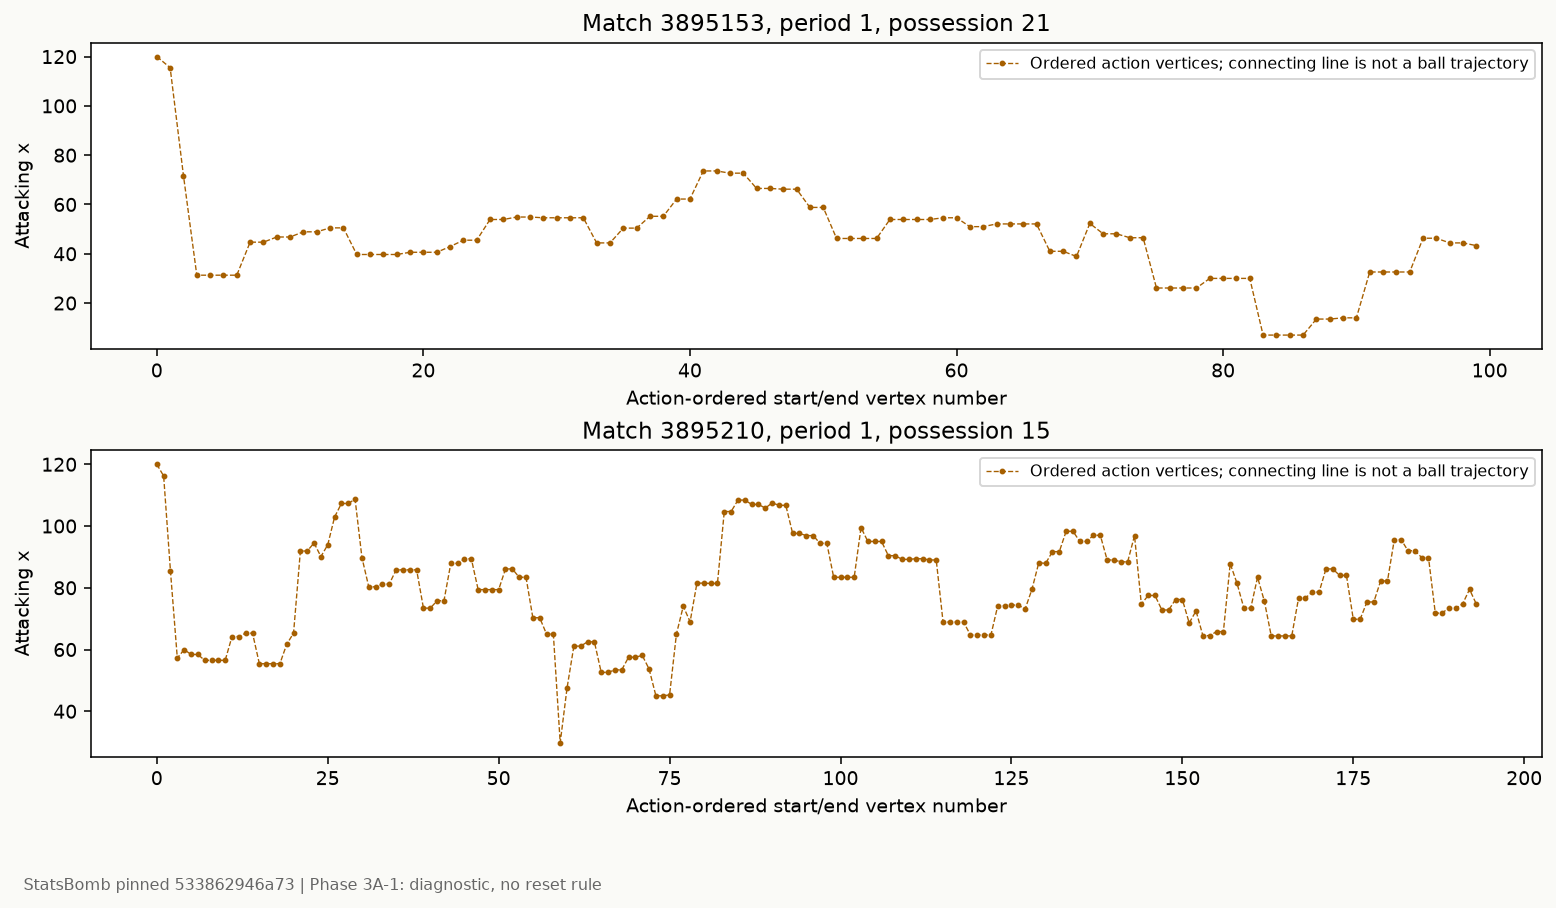

event_index,elapsed_possession_time,event_type,event_team_id,safe_action,start_x,end_x,delta_x,running_peak_x,retreat_from_peak,validated_anchor,semantics_status
1,0.0,Starting XI,904,False,NaN,NaN,NaN,NaN,NaN,False,no_360_frame
2,0.0,Starting XI,182,False,NaN,NaN,NaN,NaN,NaN,False,no_360_frame
3,0.0,Half Start,904,False,NaN,NaN,NaN,NaN,NaN,False,no_360_frame
4,0.0,Half Start,182,False,NaN,NaN,NaN,NaN,NaN,False,no_360_frame


event_index,elapsed_possession_time,event_type,event_team_id,safe_action,start_x,end_x,delta_x,running_peak_x,retreat_from_peak,validated_anchor,semantics_status
96,0.000,Pass,904,True,94.4,98.0,3.6,98.0,0.0,True,validated_core_event_team_scope
97,0.864,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
98,0.864,Pass,904,True,99.0,99.2,0.2,99.2,0.0,True,validated_core_event_team_scope
99,1.391,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
100,1.391,Carry,904,True,99.2,100.0,0.8,100.0,0.0,True,validated_core_event_team_scope
101,1.416,Pass,904,True,100.0,99.4,-0.6,100.0,0.6,True,validated_core_event_team_scope
102,1.923,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
103,1.923,Carry,904,True,99.4,98.8,-0.6,100.0,1.2,True,validated_core_event_team_scope
104,1.963,Miscontrol,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
105,2.406,Pressure,904,False,NaN,NaN,NaN,NaN,NaN,True,validated_core_event_team_scope


event_index,elapsed_possession_time,event_type,event_team_id,safe_action,start_x,end_x,delta_x,running_peak_x,retreat_from_peak,validated_anchor,semantics_status
118,0.000,Pass,904,True,80.7,92.2,11.5,92.2,0.0,True,validated_core_event_team_scope
119,0.771,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
120,0.771,Pass,904,True,92.4,92.4,0.0,92.4,0.0,True,validated_core_event_team_scope
121,1.595,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
122,1.595,Carry,904,True,92.4,106.2,13.8,106.2,0.0,True,validated_core_event_team_scope
123,1.767,Pressure,182,False,NaN,NaN,NaN,NaN,NaN,True,validated_core_event_team_scope
124,3.270,Pass,904,True,106.2,114.9,8.7,114.9,0.0,True,validated_core_event_team_scope
125,5.345,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
126,5.345,Goal Keeper,182,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
127,7.328,Pass,904,True,93.2,98.0,4.8,114.9,16.9,True,validated_core_event_team_scope


event_index,elapsed_possession_time,event_type,event_team_id,safe_action,start_x,end_x,delta_x,running_peak_x,retreat_from_peak,validated_anchor,semantics_status
162,0.000,Pass,904,True,82.7,83.7,1.0,83.7,0.0,True,validated_core_event_team_scope
163,1.368,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
164,1.368,Carry,904,True,83.7,81.7,-2.0,83.7,2.0,True,validated_core_event_team_scope
165,1.551,Pressure,182,False,NaN,NaN,NaN,NaN,NaN,True,validated_core_event_team_scope
166,1.813,Pass,904,True,81.7,88.0,6.3,88.0,0.0,True,validated_core_event_team_scope
167,2.518,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
168,2.518,Pass,904,True,86.0,66.7,-19.3,88.0,21.3,True,validated_core_event_team_scope
169,4.323,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
170,4.323,Carry,904,True,66.7,84.7,18.0,88.0,3.3,True,validated_core_event_team_scope
171,7.250,Pass,904,True,84.7,97.2,12.5,97.2,0.0,True,validated_core_event_team_scope


event_index,elapsed_possession_time,event_type,event_team_id,safe_action,start_x,end_x,delta_x,running_peak_x,retreat_from_peak,validated_anchor,semantics_status
256,0.000,Pass,904,True,57.8,63.1,5.3,63.1,0.0,True,validated_core_event_team_scope
257,1.247,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
258,1.247,Carry,904,True,63.1,64.7,1.6,64.7,0.0,True,validated_core_event_team_scope
259,2.904,Pass,904,True,64.7,69.1,4.4,69.1,0.0,True,validated_core_event_team_scope
260,3.753,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
261,3.753,Pass,904,True,69.5,62.9,-6.6,69.5,6.6,True,validated_core_event_team_scope
262,4.206,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
263,4.206,Pass,904,True,62.9,83.5,20.6,83.5,0.0,True,validated_core_event_team_scope
264,6.089,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,no_360_frame


...

event_index,elapsed_possession_time,event_type,event_team_id,safe_action,start_x,end_x,delta_x,running_peak_x,retreat_from_peak,validated_anchor,semantics_status
1286,0.000,Pass,904,False,NaN,NaN,NaN,NaN,NaN,False,no_360_frame
1287,1.104,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
1288,1.874,Pass,904,True,69.0,61.5,-7.5,69.0,7.5,True,validated_core_event_team_scope
1289,3.002,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
1290,3.002,Carry,904,True,61.5,63.1,1.6,69.0,5.9,True,validated_core_event_team_scope
1291,7.581,Pass,904,True,63.1,65.2,2.1,69.0,3.8,True,validated_core_event_team_scope
1292,8.204,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
1293,8.204,Carry,904,True,65.2,65.3,0.1,69.0,3.7,True,validated_core_event_team_scope
1294,11.168,Pass,904,True,65.3,62.7,-2.6,69.0,6.3,True,validated_core_event_team_scope
1295,11.854,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type


event_index,elapsed_possession_time,event_type,event_team_id,safe_action,start_x,end_x,delta_x,running_peak_x,retreat_from_peak,validated_anchor,semantics_status
3451,0.000,Pass,904,True,19.3,35.9,16.6,35.9,0.0,True,validated_core_event_team_scope
3452,2.223,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
3453,2.223,Carry,904,True,35.9,36.8,0.9,36.8,0.0,True,validated_core_event_team_scope
3454,2.377,Pass,904,True,36.8,49.1,12.3,49.1,0.0,True,validated_core_event_team_scope
3455,3.869,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
3456,3.869,Carry,904,True,49.1,93.8,44.7,93.8,0.0,True,validated_core_event_team_scope
3457,9.317,Pass,904,True,93.8,90.2,-3.6,93.8,3.6,True,validated_core_event_team_scope
3458,10.981,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
3459,10.981,Carry,904,True,90.2,95.2,5.0,95.2,0.0,True,validated_core_event_team_scope
3460,12.038,Pass,904,True,95.2,107.7,12.5,107.7,0.0,True,validated_core_event_team_scope


event_index,elapsed_possession_time,event_type,event_team_id,safe_action,start_x,end_x,delta_x,running_peak_x,retreat_from_peak,validated_anchor,semantics_status
2412,0.000,Pass,904,False,NaN,NaN,NaN,NaN,NaN,False,no_360_frame
2413,2.228,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
2414,2.228,Carry,904,True,87.3,85.1,-2.2,87.3,2.2,True,validated_core_event_team_scope
2415,2.423,Pressure,174,False,NaN,NaN,NaN,NaN,NaN,True,validated_core_event_team_scope
2416,2.889,Pass,904,True,85.1,62.9,-22.2,87.3,24.4,True,validated_core_event_team_scope
2417,5.105,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
2418,5.105,Carry,904,True,62.9,50.0,-12.9,87.3,37.3,True,validated_core_event_team_scope
2419,7.124,Pressure,174,False,NaN,NaN,NaN,NaN,NaN,True,validated_core_event_team_scope
2420,7.430,Pass,904,True,50.0,38.7,-11.3,87.3,48.6,True,validated_core_event_team_scope
2421,9.199,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type


event_index,elapsed_possession_time,event_type,event_team_id,safe_action,start_x,end_x,delta_x,running_peak_x,retreat_from_peak,validated_anchor,semantics_status
778,0.000,Pass,904,True,120.0,116.2,-3.8,120.0,3.8,True,validated_core_event_team_scope
779,1.522,Clearance,185,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
780,4.380,Clearance,185,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
781,5.306,Clearance,185,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
782,6.921,Ball Recovery,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
783,6.921,Carry,904,True,85.3,57.2,-28.1,120.0,62.8,True,validated_core_event_team_scope
784,9.867,Pass,904,False,NaN,NaN,NaN,NaN,NaN,False,no_360_frame
785,11.705,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
786,11.705,Carry,904,True,60.0,58.4,-1.6,120.0,61.6,True,validated_core_event_team_scope
787,14.230,Pressure,185,False,NaN,NaN,NaN,NaN,NaN,True,validated_core_event_team_scope


event_index,elapsed_possession_time,event_type,event_team_id,safe_action,start_x,end_x,delta_x,running_peak_x,retreat_from_peak,validated_anchor,semantics_status
2432,0.000,Pass,904,True,120.0,113.8,-6.2,120.0,6.2,True,validated_core_event_team_scope
2433,2.148,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
2434,2.148,Duel,190,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
2435,2.148,Shot,904,False,NaN,NaN,NaN,NaN,NaN,False,related_team_label_conflict
2436,2.460,Goal Keeper,190,False,NaN,NaN,NaN,NaN,NaN,False,no_360_frame
2437,3.164,Clearance,190,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
2438,6.116,Pass,904,True,94.8,73.0,-21.8,120.0,47.0,True,validated_core_event_team_scope
2439,8.228,Ball Receipt*,904,False,NaN,NaN,NaN,NaN,NaN,False,unsupported_event_type
2440,8.228,Carry,904,True,73.0,73.8,0.8,120.0,46.2,True,validated_core_event_team_scope
2441,9.250,Pass,904,True,73.8,87.4,13.6,120.0,32.6,True,validated_core_event_team_scope


In [8]:
display(read('duration_landmarks'))
display(read('candidate_review_possessions')[['match_id','period','possession_id','possession_duration_seconds','total_event_count','validated_spatial_anchor_count','maximum_retreat_from_peak','retreat_excursion_count','ranking_reasons']])
manifest=read('representative_possessions')
display(manifest[['match_id','period','possession_id','selection_reasons']])
figure('representative_progression_traces')
timeline=read('representative_timelines')
for row in manifest.itertuples(index=False):
    mask=(timeline.match_id.eq(row.match_id)&timeline.period.eq(row.period)&timeline.possession_id.eq(row.possession_id))
    title=f'{row.match_id} / period {row.period} / possession {row.possession_id}: {row.selection_reasons}'
    cols=['event_index','elapsed_possession_time','event_type','event_team_id','safe_action','start_x','end_x','delta_x','running_peak_x','retreat_from_peak','validated_anchor','semantics_status']
    display(HTML(f'<details><summary>{html.escape(title)}</summary>{timeline.loc[mask,cols].to_html(index=False)}</details>'))


## 9. Candidate signal inventory and literal football context
Settings are separate descriptive sweeps. No boundary strength, combined score or operational reset is assigned. The overlap table reports every cross-family setting combination for five numeric signal families. Provider tokens enumerate exact event types, supplied `out`, `counterpress`, pass types and non-Shot outcome names. These are context, not assumed hard boundaries; `provider_group_final_record` is a structural marker with prevalence 100% by construction.


In [9]:
display(read('candidate_reset_signal_inventory'))
display(read('candidate_signal_overlap').head(20))
display(read('football_termination_inventory'))


,candidate_signal,descriptive_setting,possession_count,denominator,percentage
0,provider_group_final_record,all,2888,2888,100.000000
1,provider_field,ball_receipt.outcome:Incomplete,1643,2888,56.890582
2,provider_field,counterpress:true,990,2888,34.279778
3,provider_field,duel.outcome:Lost In Play,162,2888,5.609418
4,provider_field,duel.outcome:Lost Out,110,2888,3.808864
...,...,...,...,...,...
81,observed_peak_recovery_time_above_seconds,15,519,2888,17.970914
82,unrecovered_followup_above_seconds,15,352,2888,12.188366
83,observed_peak_recovery_time_above_seconds,30,182,2888,6.301939
84,unrecovered_followup_above_seconds,30,173,2888,5.990305


,signal_a,setting_a,signal_b,setting_b,both_possessions,either_possessions,denominator
0,single_backward_action,5,cumulative_retreat_from_peak,5,1816,1965,2888
1,single_backward_action,5,cumulative_retreat_from_peak,10,1595,1908,2888
2,single_backward_action,5,cumulative_retreat_from_peak,15,1358,1887,2888
3,single_backward_action,5,cumulative_retreat_from_peak,20,1141,1870,2888
4,single_backward_action,5,cumulative_retreat_from_peak,25,939,1849,2888
5,single_backward_action,5,cumulative_retreat_from_peak,30,767,1840,2888
6,single_backward_action,5,cumulative_retreat_from_peak,40,496,1830,2888
7,single_backward_action,5,negative_run_actions,2,1377,1911,2888
8,single_backward_action,5,negative_run_actions,3,823,1833,2888
9,single_backward_action,5,negative_run_actions,4,394,1820,2888


,signal,event_type,event_team_id,next_event_type,next_possession_team_id,event_count,match_count
0,ball_receipt.outcome:Incomplete,Ball Receipt*,169,Ball Recovery,904.0,9,2
1,ball_receipt.outcome:Incomplete,Ball Receipt*,169,Block,904.0,1,1
2,ball_receipt.outcome:Incomplete,Ball Receipt*,169,Clearance,904.0,1,1
3,ball_receipt.outcome:Incomplete,Ball Receipt*,169,Duel,904.0,2,2
4,ball_receipt.outcome:Incomplete,Ball Receipt*,169,Foul Committed,904.0,1,1
...,...,...,...,...,...,...,...
3137,type:Shot,Shot,904,Goal Keeper,190.0,1,1
3138,type:Shot,Shot,904,Goal Keeper,201.0,3,2
3139,type:Shot,Shot,904,Goal Keeper,872.0,1,1
3140,type:Shot,Shot,904,Goal Keeper,904.0,397,34


## 10. What remains unresolved for Phase 3A-2
Phase 3A-1 is DIAGNOSTIC / NOT A METHOD LOCK. The next step is **Phase 3A-2 — Representative Possession / Boundary Review**, followed by Phase 3A-3 segmentation calibration and method lock.

Human review should compare single-vector retreat with cumulative observed peak retreat, strict versus zero-tolerant runs, event/action/anchor gaps and observed/censored recovery intervals. It must inspect missing actions, endpoint-time uncertainty, inter-action coordinate discontinuity and literal provider stoppage/restart context. No threshold is promoted from prevalence, and no future effectiveness is used to select a signal. Final episode units, segmentation, eligibility and outcomes remain open.

See the Phase 3A-1 sections of [methods](../docs/methods_specification.md) and [technical appendix](../report/technical_appendix.md) for measured findings and limitations.


Measured support: 37,984 safe vectors cover 2,662 of 2,888 parents. Median Pass/Carry delta-x is 2.3/0.2 units; measurable-parent net/forward/backward medians are 31.0/57.75/18.1. Maximum retreat has median/p90 16.8/53.2. There are 4,781 record-peak excursions, including 3,519 observed returns and 1,262 censored cases; conditional median recovery timestamp span is 5.008 seconds.

The two plotted examples both start with provider Corner records at x=120. There are 171 parents whose first safe action starts at 120, illustrating why record-peak recovery can miss renewed local rises. Another selected case has only nonnegative explicit action vectors but 21.7 units of peak retreat from inter-action coordinate jumps. These are specific priorities for contextual human review, not evidence for a reset threshold.
